# Przygotowanie środowiska

In [1]:
from pathlib import Path

# aktualny katalog roboczy notebooka
current_dir = Path.cwd()

scene = "room_0"

data_path = current_dir.parent / "sound-spaces/data/scene_datasets/replica"

scene_config = data_path / scene / "habitat/replica_stage.stage_config.json"

print("Aktualny katalog:", current_dir)
print("Dataset:", data_path)
print("Scene config:", scene_config)
print("Istnieje:", scene_config.exists())

Aktualny katalog: /home/d4krzyk/Dokumenty/MasterWorkVE/my-operations
Dataset: /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica
Scene config: /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_0/habitat/replica_stage.stage_config.json
Istnieje: True


In [2]:
import habitat_sim

print("1. import OK")

cfg = habitat_sim.SimulatorConfiguration()

print("2. cfg OK")

cfg.scene_dataset_config_file = (
    str(data_path) + "/replica.scene_dataset_config.json"
)
cfg.scene_id = scene
# habitat_sim.Simulator overrides create_renderer based on whether any agent
# has sensors (see simulator.py:_sanitize_config) - setting it directly here
# has no effect. Without a sensor, the renderer stays off and PTex (Replica)
# stage loading aborts in PTexMeshData::getRenderingBuffer (the kernel crash
# seen below before this fix). A sensor is required even if RGB isn't used.
cfg.create_renderer = True
cfg.gpu_device_id = 0

print("3. config OK")

rgb_sensor_spec = habitat_sim.CameraSensorSpec()
rgb_sensor_spec.uuid = "color_sensor"
rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
rgb_sensor_spec.resolution = [128, 128]

agent_cfg = habitat_sim.agent.AgentConfiguration()
agent_cfg.sensor_specifications = [rgb_sensor_spec]

print("4. agent OK")

1. import OK
2. cfg OK
3. config OK
4. agent OK


In [3]:
sim = habitat_sim.Simulator(
    habitat_sim.Configuration(cfg, [agent_cfg])
)

print("5. SIM OK")

5. SIM OK
[18:00:27:781884]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.json from original name : default| This file does not exist.
[18:00:27:782832]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[18:00:27:782905]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[18:00:27:782946]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneSolid:coneSolid_segments_12_halfLen_1.25_rings_1_useTexCoords_false_useTangents_false_capEnd_true) created and registered.
[18:00:27:782982]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (coneWireframe:coneW

[18:00:27:785208]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[18:00:27:785616]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/*_[0-9]/habitat/replica_stage.stage_config.json : /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/apartment_0/habitat/replica_stage.stage_config.json
[18:00:27:786200]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/*_[0-9]/habitat/replica_stage.stage_config.json : /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/apartment_1/habitat/replica_stage.stage_config.json
[18:00:27:786515]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob

umenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_0/habitat/replica_stage.stage_config.json from original name : /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_0/habitat/replica_stage.stage_config.json| This file exists.
[18:00:27:790058]:[Metadata] AbstractObjectAttributesManagerBase.h(184)::createObject : JSON Configuration File (/home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_0/habitat/replica_stage.stage_config.json) based Stage Template attributes created and registered.
[18:00:27:790076]:[Metadata] AttributesManagerBase.h(285)::loadAllFileBasedTemplates : <Stage Template> : Loaded file-based templates: 1
[18:00:27:790109]:[Metadata] AttributesManagerBase.h(265)::loadAllFileBasedTemplates : Loading 1  Stage Template templates found in /home/d4krzyk/Dokumenty/MasterWorkVE/sound-spaces/data/scene_datasets/replica/room_1/habitat
[18:00:27:790128]:[Metadata] AttributesManagerBase.h(380)::createFromJ

# Analiza architektury i danych

In [4]:
import pickle
import networkx as nx
import numpy as np

# Wczytanie grafu dla konkretnej sceny
with open(f'metadata/replica/{scene}/graph.pkl', 'rb') as f:
    graph = pickle.load(f)

# Wyciągnięcie pozycji XYZ wszystkich punktów
# location_id w Twoim DataFrame to indeks na tej liście
node_positions = [np.asarray(graph.nodes[n]['point'], dtype=float) for n in graph.nodes()]

# Przykład: lokalizacja o ID 4 z Twojego pliku .pkl
id = 50
target_xyz = node_positions[id]
print(f"Dla location_id={id}, fizyczne współrzędne to: {target_xyz}")

Dla location_id=50, fizyczne współrzędne to: [ 4.752906  -1.5491767 -1.913136 ]


In [5]:
import numpy as np
import pandas as pd
meta_points = pd.read_csv(f'metadata/replica/{scene}/points.txt', delimiter='\t')
print((meta_points.head(130)))

       0  -0.747094  -0.586864  0.003714
0      1  -0.747094  -0.086864  0.003714
1      2  -0.747094   0.413136  0.003714
2      3  -0.747094   0.913136  0.003714
3      4  -0.747094   1.413136  0.003714
4      5  -0.747094   1.913136  0.003714
..   ...        ...        ...       ...
125  126   6.252906   2.413136  0.003714
126  127   6.252906   2.913136  0.003714
127  128   6.752906  -1.086864  0.003714
128  129   6.752906  -0.586864  0.003714
129  130   6.752906  -0.086864  0.003714

[130 rows x 4 columns]


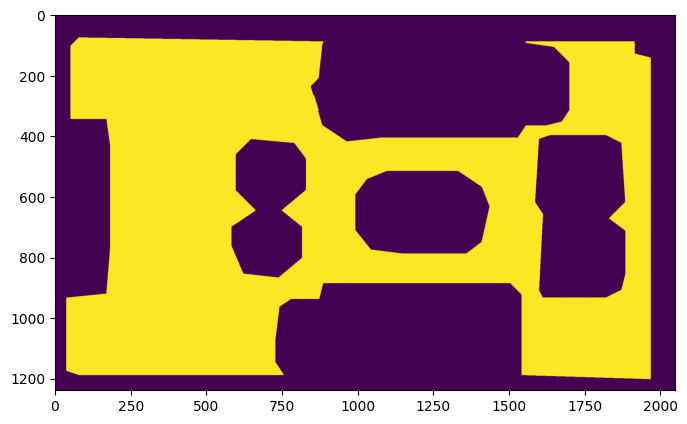

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import habitat_sim

# zakładam że sim już istnieje i navmesh jest załadowany

# 1. top-down render navmesh
bounds = sim.pathfinder.get_bounds()
min_b, max_b = bounds

meters_per_pixel = max(max_b[0] - min_b[0], max_b[2] - min_b[2]) / 2048.0
height = float(node_positions[0][1])

topdown = sim.pathfinder.get_topdown_view(meters_per_pixel, height)

plt.figure(figsize=(8, 8))
plt.imshow(topdown, origin="upper")
#print(min_b, max_b)

In [7]:
import pickle
import numpy as np

# 1) Przygotuj współrzędne punktów (spróbuj użyć zmiennej `points` jeśli istnieje)
points = np.array(node_positions)  # Zakładam, że node_positions to lista [ID, x, y, z]
ids = points[:, 0].astype(int)
coords = points[:, 1:4].astype(float)
order = np.argsort(ids)
coords_sorted = coords[order]

# 2) oblicz odległości między sąsiednimi punktami (ID i ID+1)
diffs = coords_sorted[1:] - coords_sorted[:-1]
dists = np.linalg.norm(diffs, axis=1)

# 3) wyświetl pierwsze 30 odległości oraz podstawowe statystyki
for idx, dist in enumerate(dists[:10]):
    print(f"id {idx} -> {idx+1}: {dist:.3f} m")

print()
print("Statystyki:")
print("  count:", len(dists))
print("  mean: {:.3f} m".format(dists.mean()))
print("  median: {:.3f} m".format(np.median(dists)))
print("  min: {:.3f} m".format(dists.min()))
print("  max: {:.3f} m".format(dists.max()))

id 0 -> 1: 3.500 m
id 1 -> 2: 0.500 m
id 2 -> 3: 0.500 m
id 3 -> 4: 0.500 m
id 4 -> 5: 0.500 m
id 5 -> 6: 0.500 m
id 6 -> 7: 0.500 m
id 7 -> 8: 3.000 m
id 8 -> 9: 0.500 m
id 9 -> 10: 3.000 m

Statystyki:
  count: 50
  mean: 1.230 m
  median: 0.750 m
  min: 0.000 m
  max: 3.500 m


In [8]:
import pickle
import pandas as pd

with open("../scenes_ve_metadata_locations/scene_observations_128.pkl", "rb") as f:
    observations = pickle.load(f)

observations.keys()

dict_keys(['apartment_0', 'apartment_1', 'apartment_2', 'frl_apartment_0', 'frl_apartment_1', 'frl_apartment_2', 'frl_apartment_3', 'frl_apartment_4', 'frl_apartment_5', 'office_0', 'office_1', 'office_2', 'office_3', 'office_4', 'hotel_0', 'room_0', 'room_1', 'room_2'])

In [9]:
observations[scene]

{(8,
  0): {'rgb': array([[[222, 218, 216, 255],
          [223, 218, 217, 255],
          [223, 218, 217, 255],
          ...,
          [197, 188, 191, 255],
          [197, 188, 191, 255],
          [196, 188, 190, 255]],
  
         [[223, 218, 217, 255],
          [223, 218, 217, 255],
          [223, 218, 217, 255],
          ...,
          [195, 186, 189, 255],
          [195, 187, 189, 255],
          [191, 182, 185, 255]],
  
         [[223, 218, 216, 255],
          [223, 219, 217, 255],
          [223, 218, 217, 255],
          ...,
          [193, 185, 187, 255],
          [191, 182, 184, 255],
          [193, 186, 190, 255]],
  
         ...,
  
         [[207, 201, 199, 255],
          [207, 199, 198, 255],
          [205, 197, 197, 255],
          ...,
          [154, 148, 151, 255],
          [155, 147, 147, 255],
          [155, 148, 148, 255]],
  
         [[206, 199, 198, 255],
          [205, 197, 197, 255],
          [203, 195, 194, 255],
          ...,
          [

In [10]:
test_node = {k: w for k, w in observations[scene].items() if k[0] == 8 and k[1] == 0}

print("Key:", list(test_node.items())[0][0])
print("rgb shape:", test_node[(8, 0)]["rgb"].shape)
print("rgb values:", test_node[(8, 0)]["rgb"][:1][0][:5])

Key: (8, 0)
rgb shape: (128, 128, 4)
rgb values: [[222 218 216 255]
 [223 218 217 255]
 [223 218 217 255]
 [223 219 217 255]
 [223 219 217 255]]


In [11]:
# Lzejszy podglad RGB dla apartment_0 z filtrem orientation (0/90/180/270)
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


orientations = [0, 90, 180, 270]
state = {"idx": 0}
states = observations.get(scene, {})

def build_frames(orientation):
    frames = []
    for (loc, ori), obs in sorted(states.items(), key=lambda x: x[0][0]):
        if ori != orientation:
            continue
        rgb = obs.get("rgb")
        if rgb is None:
            continue
        frames.append((loc, rgb))
    return frames

out = widgets.Output()
btn_left = widgets.Button(description="Orientation -90")
btn_right = widgets.Button(description="Orientation +90")
play = widgets.Play(interval=200, value=0, min=0, max=0, step=1, description="Play")
slider = widgets.IntSlider(value=0, min=0, max=0, step=1, description="Frame")
widgets.jslink((play, "value"), (slider, "value"))

def render_frame(frames, idx, orientation):
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.axis("off")
        loc, rgb = frames[idx]
        ax.imshow(rgb)
        ax.set_title(f"{scene} | location_id={loc} | orientation={orientation}", fontsize=10)
        display(fig)
        plt.close(fig)

def refresh(orientation):
    frames = build_frames(orientation)
    if not frames:
        raise ValueError(f"Brak klatek RGB dla orientation={orientation} w tej scenie.")
    prev_idx = min(slider.value, len(frames) - 1)
    slider.max = len(frames) - 1
    play.max = len(frames) - 1
    slider.value = prev_idx
    render_frame(frames, slider.value, orientation)

    def on_value_change(change):
        if change["name"] == "value":
            render_frame(frames, change["new"], orientation)

    slider.unobserve_all()
    slider.observe(on_value_change, names="value")

def change_orientation(delta):
    state["idx"] = (state["idx"] + delta) % len(orientations)
    refresh(orientations[state["idx"]])

btn_left.on_click(lambda _btn: change_orientation(-1))
btn_right.on_click(lambda _btn: change_orientation(1))

controls = widgets.HBox([btn_left, btn_right, play, slider])
display(controls)
display(out)
refresh(orientations[state["idx"]])

Output()

In [12]:
rows = []

for scene_name, states in observations.items():
    for (loc, ori), obs in states.items():
        rows.append({
            "scene": scene_name,
            "location_id": loc,
            "orientation": ori,
            "has_rgb": obs["rgb"] is not None,
            "has_depth": obs["depth"] is not None
        })

df = pd.DataFrame(rows)

print(df[df["scene"] == scene].head(10))

observ_ids = df[df["scene"] == scene]['location_id'].unique()
print(observ_ids)
print(len(observ_ids))

       scene  location_id  orientation  has_rgb  has_depth
6404  room_0            8            0     True       True
6405  room_0            8           90     True       True
6406  room_0            8          180     True       True
6407  room_0            8          270     True       True
6408  room_0            9            0     True       True
6409  room_0            9           90     True       True
6410  room_0            9          180     True       True
6411  room_0            9          270     True       True
6412  room_0           14            0     True       True
6413  room_0           14           90     True       True
[  8   9  14  15  16  17  18  19  20  21  22  23  25  26  27  28  29  30
  31  32  34  35  36  37  38  39  40  41  43  44  49  50  54  55  57  58
  59  63  64  65  66  71  74  79  82  87  90  95  96  97  98 102 103 111
 112 120 121]
57


# Rysowanie mapy dla danej sceny

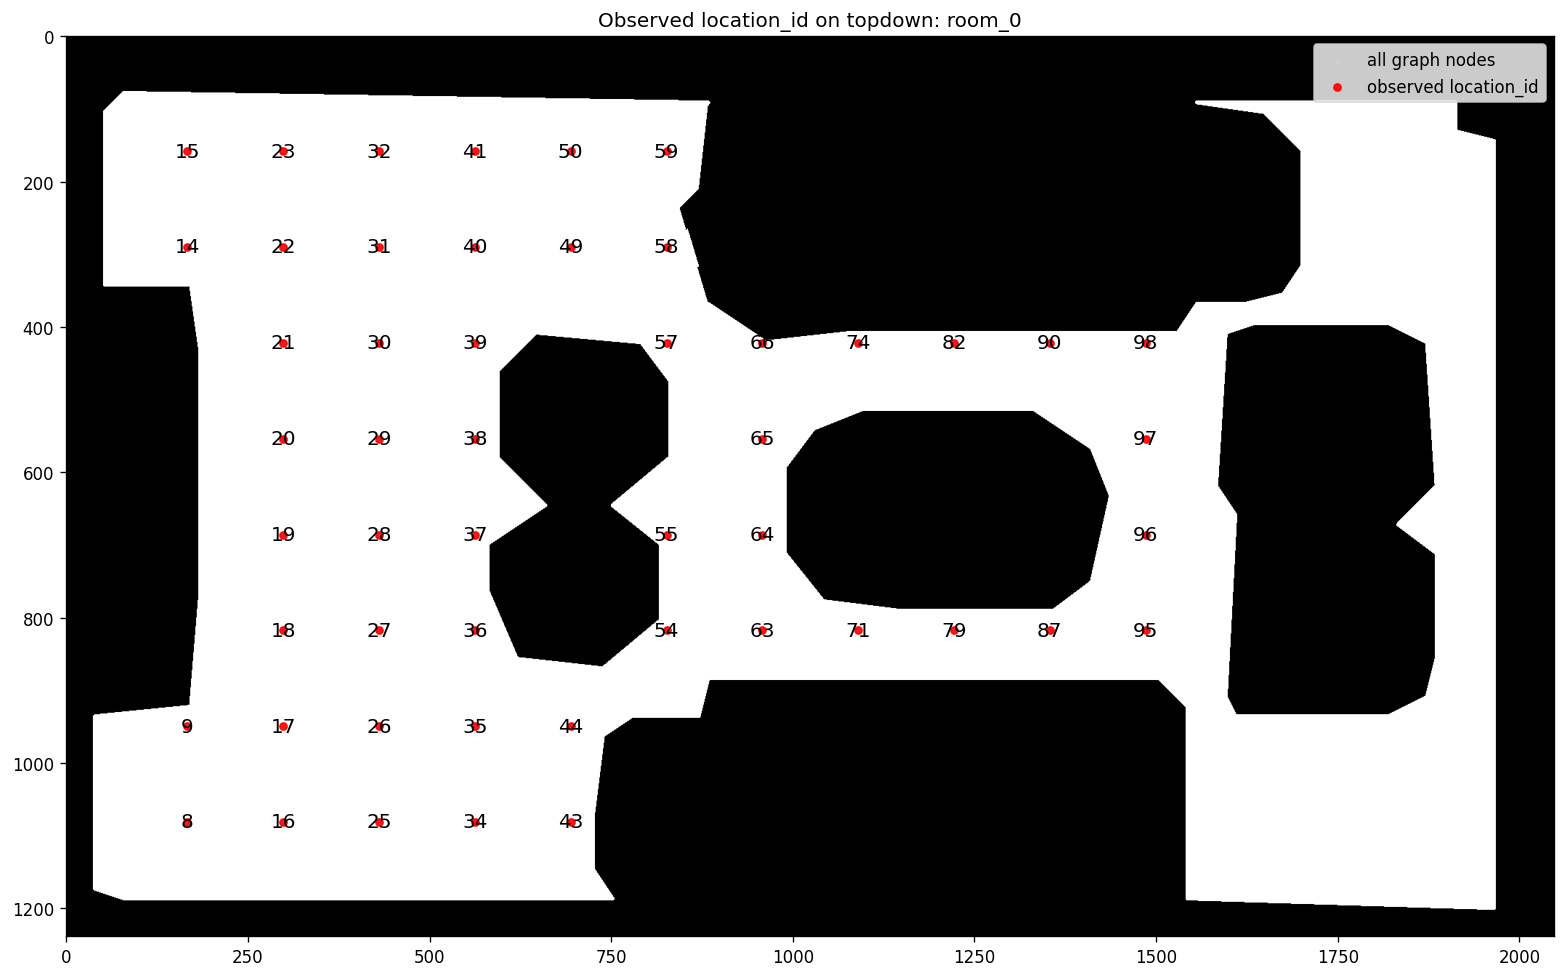

Total graph nodes: 51, Observed location_id in graph: 51


In [13]:
# Overlay graph nodes with location_id labels from observations
import matplotlib.pyplot as plt
import numpy as np

# Load graph if not already in memory
if "graph" not in globals():
    import pickle
    with open(f"metadata/replica/{scene}/graph.pkl", "rb") as f:
        graph = pickle.load(f)

# Map node id -> (x, y, z) position
node_positions = {}
for n, data in graph.nodes(data=True):
    pos = None
    if isinstance(data, dict):
        pos = data.get("point")
    elif isinstance(data, (list, tuple)) and len(data) >= 3:
        pos = data[:3]
    if pos is not None:
        node_positions[int(n)] = np.asarray(pos, dtype=float)

if len(node_positions) == 0:
    raise ValueError("No node positions found in graph node attributes.")

# All nodes (background)
all_ids = sorted(node_positions.keys())
all_pts = np.vstack([node_positions[i] for i in all_ids])
all_px = (all_pts[:, 0] - min_b[0]) / meters_per_pixel
all_pz = (all_pts[:, 2] - min_b[2]) / meters_per_pixel

# Observed nodes (labeled)
observ_ids_in_graph = [i for i in observ_ids if i in node_positions]
if len(observ_ids_in_graph) > 0:
    obs_pts = np.vstack([node_positions[i] for i in observ_ids_in_graph])
    obs_px = (obs_pts[:, 0] - min_b[0]) / meters_per_pixel
    obs_pz = (obs_pts[:, 2] - min_b[2]) / meters_per_pixel
else:
    obs_px = np.array([])
    obs_pz = np.array([])

plt.figure(figsize=(16, 16), dpi=120)
plt.imshow(topdown, origin="upper", cmap="gray")
plt.scatter(all_px, all_pz, s=6, c="lightgray", alpha=0.5, label="all graph nodes")
plt.scatter(obs_px, obs_pz, s=18, c="red", alpha=0.9, label="observed location_id")

# Add location_id labels
for loc_id, x_px, z_px in zip(observ_ids_in_graph, obs_px, obs_pz):
    plt.text(x_px, z_px, str(loc_id), color="black", fontsize=12, ha="center", va="center")

plt.legend()
plt.title(f"Observed location_id on topdown: {scene}")
plt.show()
print(f"Total graph nodes: {len(all_ids)}, Observed location_id in graph: {len(observ_ids_in_graph)}")

# Porównanie punktów z metadanych do ilości obserwacji z wygnerowanych RIR

In [14]:

print(f"Pobrano {len(all_pts)} lokalizacji dla tej sceny [{scene}].")

Pobrano 51 lokalizacji dla tej sceny [room_0].


In [15]:
print(df.groupby("scene")["location_id"].nunique())


scene
apartment_0        211
apartment_1        176
apartment_2        142
frl_apartment_0    130
frl_apartment_1    130
frl_apartment_2    125
frl_apartment_3    147
frl_apartment_4    127
frl_apartment_5    148
hotel_0             48
office_0            26
office_1            16
office_2            37
office_3            62
office_4            76
room_0              57
room_1              35
room_2              47
Name: location_id, dtype: int64


# Skrypt dla wszystkich scen

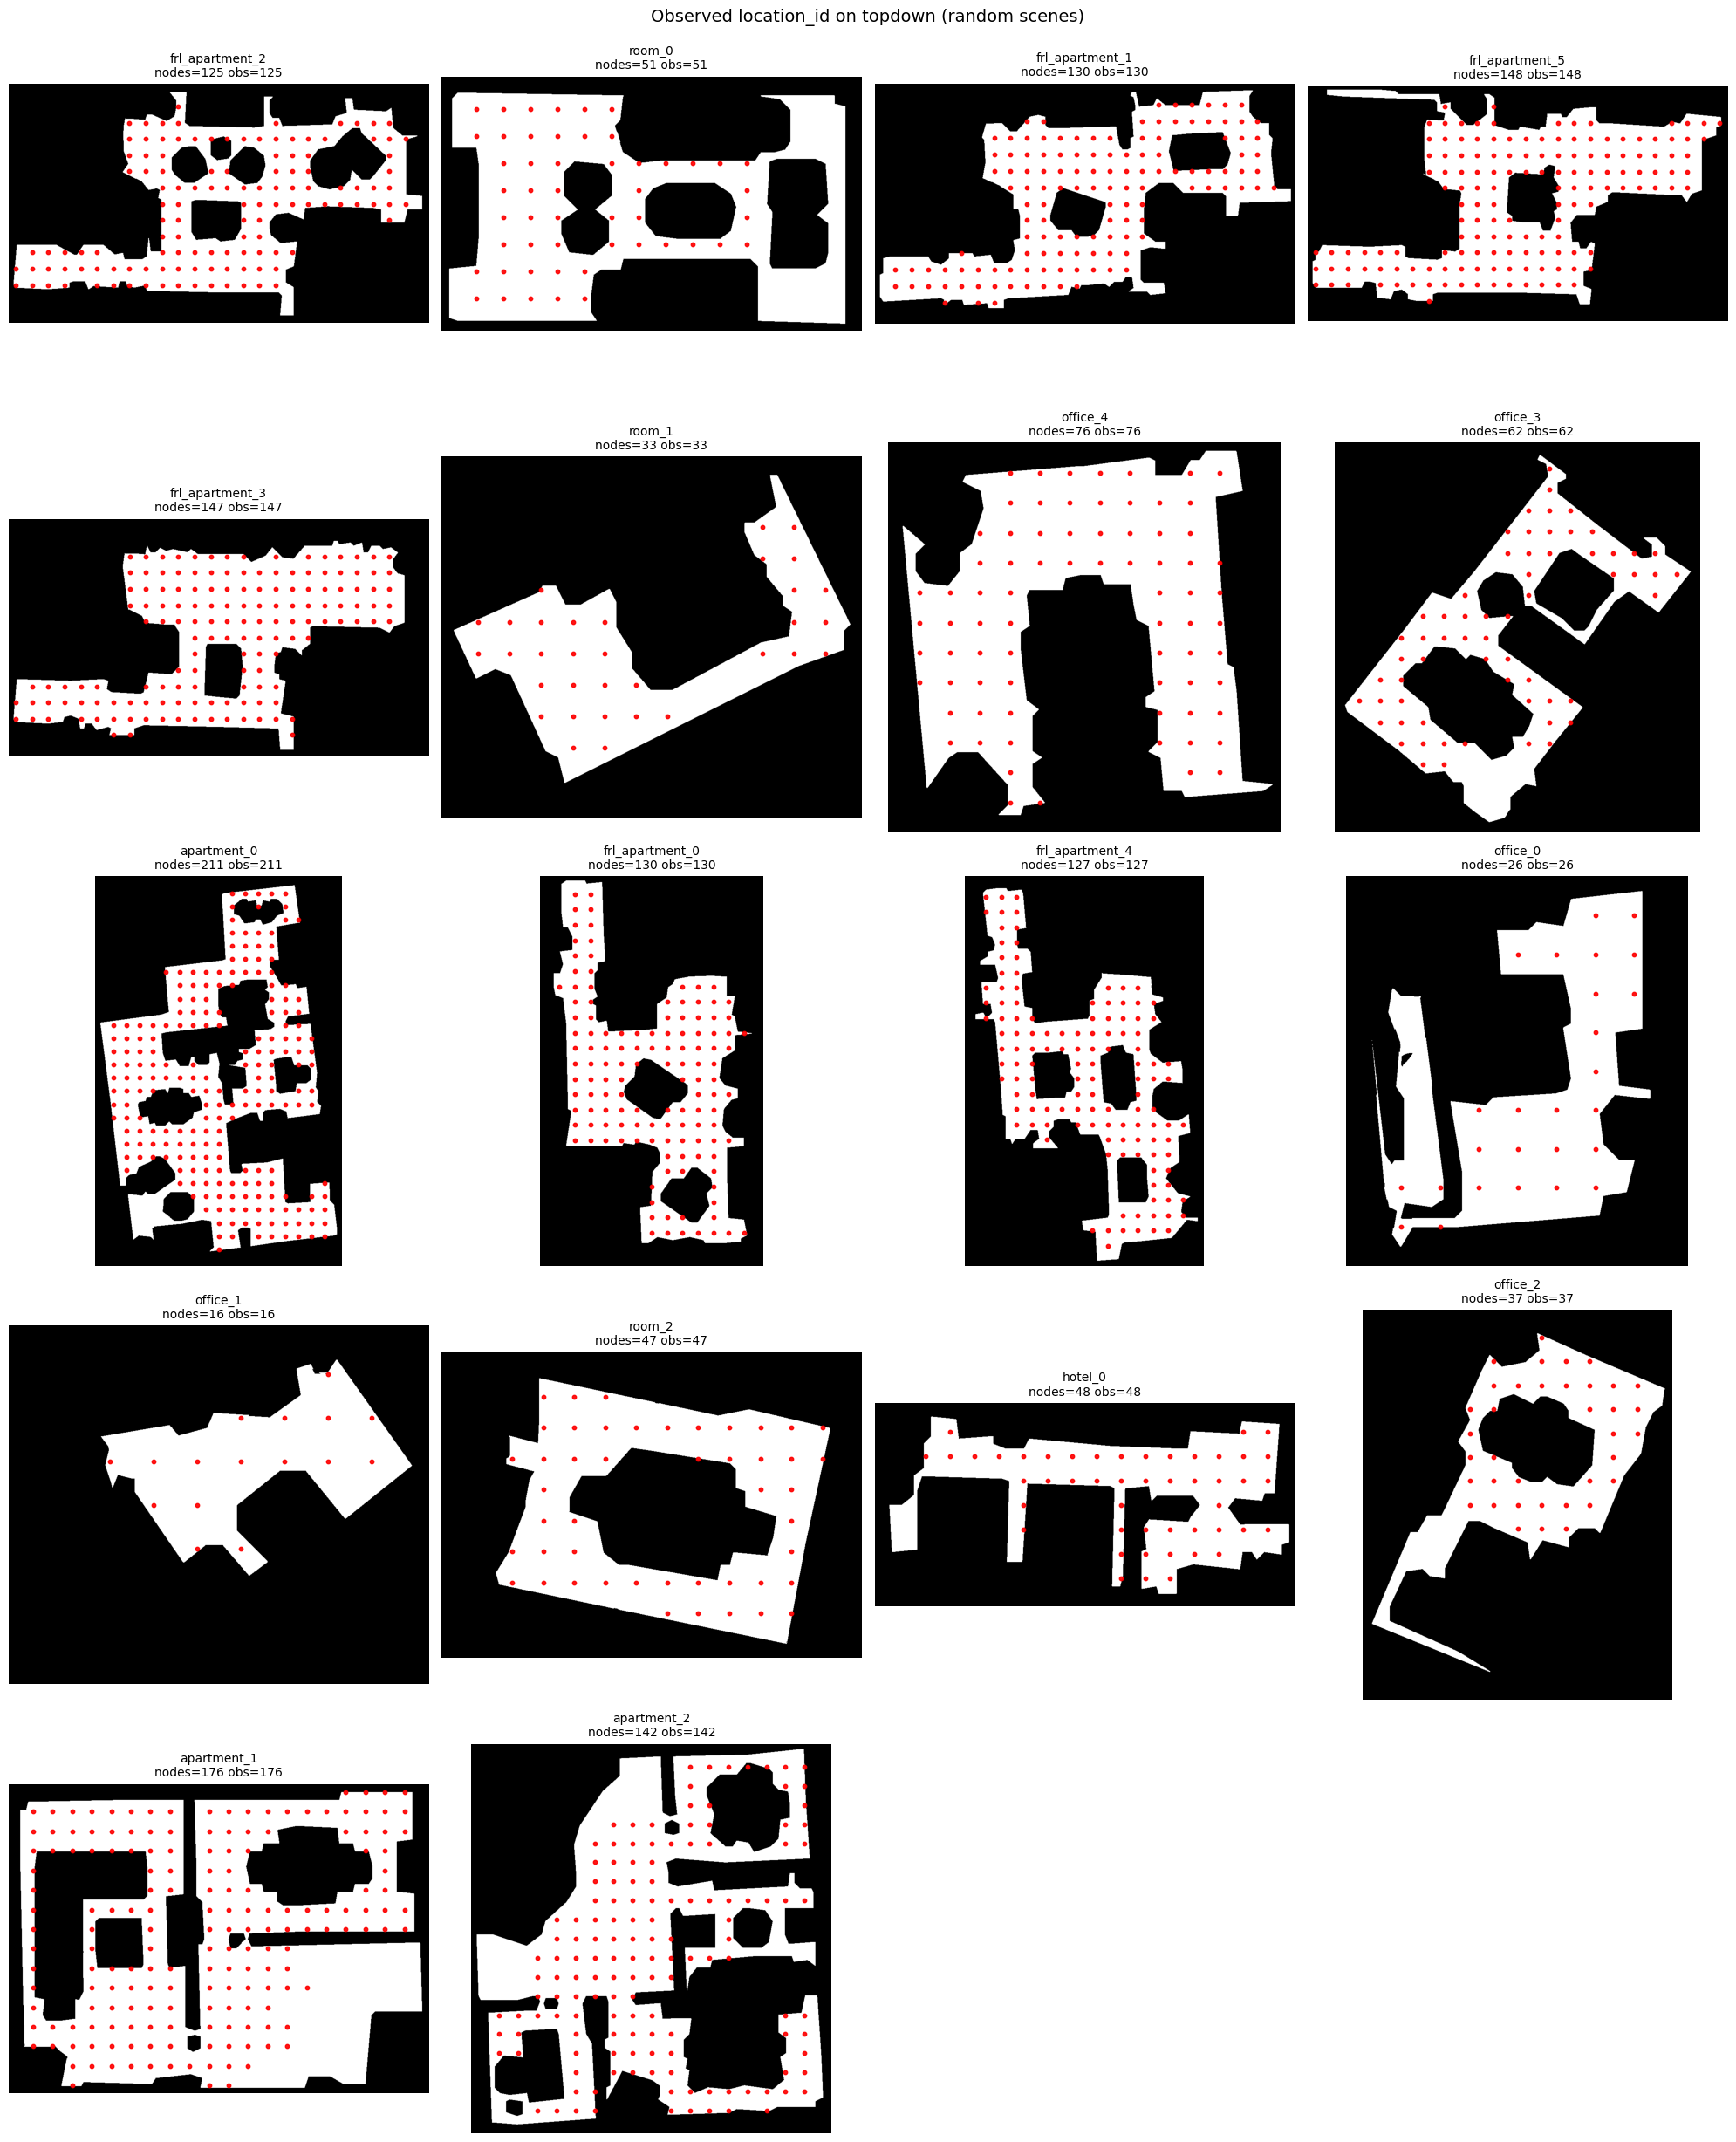

Random scenes: ['frl_apartment_2', 'room_0', 'frl_apartment_1', 'frl_apartment_5', 'frl_apartment_3', 'room_1', 'office_4', 'office_3', 'apartment_0', 'frl_apartment_0', 'frl_apartment_4', 'office_0', 'office_1', 'room_2', 'hotel_0', 'office_2', 'apartment_1', 'apartment_2']


In [16]:
# Batch overlay for random scenes - one Simulator per scene (proven pattern,
# same as the earlier per-scene approach), shown together in a grid.
# HABITAT_SIM_LOG / MAGNUM_LOG are set to "quiet" to drop the usual
# navmesh/backend log lines so the output here stays clean.
import os
os.environ["HABITAT_SIM_LOG"] = "quiet"
os.environ["MAGNUM_LOG"] = "quiet"

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import habitat_sim
import pickle

data_path = "../sound-spaces/data/scene_datasets/replica"

def render_scene(ax, scene, observations, data_path):
    scene_config = os.path.join(data_path, scene, "habitat/replica_stage.stage_config.json")
    navmesh_path = os.path.join(data_path, scene, "habitat/mesh_semantic.navmesh")
    graph_path = f"metadata/replica/{scene}/graph.pkl"

    ax.axis("off")
    if not (os.path.exists(scene_config) and os.path.exists(graph_path)):
        ax.set_title(f"{scene}\n(brak danych)", fontsize=10)
        return

    cfg = habitat_sim.SimulatorConfiguration()
    cfg.scene_id = scene_config
    # A sensor is required for create_renderer to actually take effect (see
    # the "Przygotowanie środowiska" cell) - without one, Replica stages crash.
    cfg.create_renderer = True
    cfg.enable_physics = False
    cfg.gpu_device_id = 0

    rgb_sensor_spec = habitat_sim.CameraSensorSpec()
    rgb_sensor_spec.uuid = "color_sensor"
    rgb_sensor_spec.sensor_type = habitat_sim.SensorType.COLOR
    rgb_sensor_spec.resolution = [128, 128]
    agent_cfg = habitat_sim.agent.AgentConfiguration()
    agent_cfg.sensor_specifications = [rgb_sensor_spec]

    sim_local = habitat_sim.Simulator(habitat_sim.Configuration(cfg, [agent_cfg]))
    try:
        if os.path.exists(navmesh_path):
            sim_local.pathfinder.load_nav_mesh(navmesh_path)
        if not sim_local.pathfinder.is_loaded:
            ax.set_title(f"{scene}\n(brak navmesh)", fontsize=10)
            return

        with open(graph_path, "rb") as f:
            graph = pickle.load(f)

        node_positions = {}
        for n, node_data in graph.nodes(data=True):
            pos = None
            if isinstance(node_data, dict):
                pos = node_data.get("point")
            elif isinstance(node_data, (list, tuple)) and len(node_data) >= 3:
                pos = node_data[:3]
            if pos is not None:
                node_positions[int(n)] = np.asarray(pos, dtype=float)
        if not node_positions:
            ax.set_title(f"{scene}\n(brak węzłów)", fontsize=10)
            return

        bounds = sim_local.pathfinder.get_bounds()
        min_b, max_b = bounds
        meters_per_pixel = max(max_b[0] - min_b[0], max_b[2] - min_b[2]) / 1024.0
        height = float(np.mean([p[1] for p in node_positions.values()]))
        topdown = sim_local.pathfinder.get_topdown_view(meters_per_pixel, height)

        all_ids = sorted(node_positions.keys())
        all_pts = np.vstack([node_positions[i] for i in all_ids])
        all_px = (all_pts[:, 0] - min_b[0]) / meters_per_pixel
        all_pz = (all_pts[:, 2] - min_b[2]) / meters_per_pixel

        observ_ids = sorted({loc for (loc, _ori) in observations[scene].keys() if loc in node_positions})
        if observ_ids:
            obs_pts = np.vstack([node_positions[i] for i in observ_ids])
            obs_px = (obs_pts[:, 0] - min_b[0]) / meters_per_pixel
            obs_pz = (obs_pts[:, 2] - min_b[2]) / meters_per_pixel
        else:
            obs_px, obs_pz = np.array([]), np.array([])

        ax.imshow(topdown, origin="upper", cmap="gray")
        ax.scatter(all_px, all_pz, s=3, c="lightgray", alpha=0.5)
        ax.scatter(obs_px, obs_pz, s=10, c="red", alpha=0.9)
        ax.set_title(f"{scene}\nnodes={len(all_ids)} obs={len(observ_ids)}", fontsize=10)
    finally:
        sim_local.close()

# Pick random scenes and render them into one grid
all_scenes = sorted(observations.keys())
sample_count = min(20, len(all_scenes))
random_scenes = random.sample(all_scenes, sample_count)

ncols = 4
nrows = math.ceil(sample_count / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
axes = np.atleast_1d(axes).flatten()

for ax, scene in zip(axes, random_scenes):
    render_scene(ax, scene, observations, data_path)
for ax in axes[len(random_scenes):]:
    ax.axis("off")

fig.suptitle("Observed location_id on topdown (random scenes)", fontsize=14)
plt.tight_layout()
plt.show()

print("Random scenes:", random_scenes)

In [17]:
# Check counts: metadata nodes vs observation locations
def compare_counts(scene, observations):
    graph_path = f"metadata/replica/{scene}/graph.pkl"
    if not os.path.exists(graph_path):
        return (scene, None, None, "missing graph")
    with open(graph_path, "rb") as f:
        graph = pickle.load(f)

    node_count = graph.number_of_nodes() if hasattr(graph, "number_of_nodes") else len(graph)
    obs_count = len({loc for (loc, _ori) in observations[scene].keys()})
    status = "OK" if node_count == obs_count else "DIFF"
    return (scene, node_count, obs_count, status)

results = [compare_counts(s, observations) for s in random_scenes]
for scene_name, node_count, obs_count, status in results:
    print(f"{scene_name}: nodes={node_count}, observations={obs_count} -> {status}")

frl_apartment_2: nodes=125, observations=125 -> OK
room_0: nodes=51, observations=57 -> DIFF
frl_apartment_1: nodes=130, observations=130 -> OK
frl_apartment_5: nodes=148, observations=148 -> OK
frl_apartment_3: nodes=147, observations=147 -> OK
room_1: nodes=33, observations=35 -> DIFF
office_4: nodes=76, observations=76 -> OK
office_3: nodes=62, observations=62 -> OK
apartment_0: nodes=211, observations=211 -> OK
frl_apartment_0: nodes=130, observations=130 -> OK
frl_apartment_4: nodes=127, observations=127 -> OK
office_0: nodes=26, observations=26 -> OK
office_1: nodes=16, observations=16 -> OK
room_2: nodes=47, observations=47 -> OK
hotel_0: nodes=48, observations=48 -> OK
office_2: nodes=37, observations=37 -> OK
apartment_1: nodes=176, observations=176 -> OK
apartment_2: nodes=142, observations=142 -> OK
